iniciar sesion de spark y cargar librerias

In [1]:
from pyspark.sql import SparkSession
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.sql.functions import col

# Iniciar sesión de Spark configurada para tu parcial
spark = SparkSession.builder \
    .appName("Parcial_ML_ValentinaMuñoz") \
    .getOrCreate()

# 2. Cargar los datos desde la carpeta que mapeamos en Docker
# Usamos inferSchema=True para que reconozca los números automáticamente
df_train = spark.read.csv("../datos/train.csv", header=True, inferSchema=True)
df_test = spark.read.csv("../datos/test.csv", header=True, inferSchema=True)

print(f"Dimensiones de entrenamiento: ({df_train.count()}, {len(df_train.columns)})")

Dimensiones de entrenamiento: (199364, 31)


In [2]:
# Ver el esquema de los datos (Catálogo de variables)
df_train.printSchema()

# Ver las primeras filas de forma organizada
df_train.show(5, truncate=False)

root
 |-- Time: double (nullable = true)
 |-- V1: double (nullable = true)
 |-- V2: double (nullable = true)
 |-- V3: double (nullable = true)
 |-- V4: double (nullable = true)
 |-- V5: double (nullable = true)
 |-- V6: double (nullable = true)
 |-- V7: double (nullable = true)
 |-- V8: double (nullable = true)
 |-- V9: double (nullable = true)
 |-- V10: double (nullable = true)
 |-- V11: double (nullable = true)
 |-- V12: double (nullable = true)
 |-- V13: double (nullable = true)
 |-- V14: double (nullable = true)
 |-- V15: double (nullable = true)
 |-- V16: double (nullable = true)
 |-- V17: double (nullable = true)
 |-- V18: double (nullable = true)
 |-- V19: double (nullable = true)
 |-- V20: double (nullable = true)
 |-- V21: double (nullable = true)
 |-- V22: double (nullable = true)
 |-- V23: double (nullable = true)
 |-- V24: double (nullable = true)
 |-- V25: double (nullable = true)
 |-- V26: double (nullable = true)
 |-- V27: double (nullable = true)
 |-- V28: double (nulla

In [3]:
# 1. Resumen estadístico de las variables numéricas (Time y Amount)
df_train.select("Time", "Amount", "Class").describe().show()

# 2. Ver una muestra de los datos
df_train.limit(5).toPandas()

+-------+-----------------+------------------+--------------------+
|summary|             Time|            Amount|               Class|
+-------+-----------------+------------------+--------------------+
|  count|           199364|            199364|              199364|
|   mean|94898.21151762606|  88.3847836118836|0.001725487048815...|
| stddev|47489.93116671869|253.06608054959918|0.041503233408096474|
|    min|              0.0|               0.0|                   0|
|    max|         172792.0|          25691.16|                   1|
+-------+-----------------+------------------+--------------------+



,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,154640.0,-0.012102,0.707332,0.163334,-0.756498,0.590999,-0.653429,0.844608,-0.001672,-0.184399,...,-0.231385,-0.572415,0.042660,-0.360882,-0.494703,0.142657,0.235922,0.083758,7.13,0
1,139525.0,1.776151,-0.184642,-2.204096,1.191668,0.614461,-1.016525,0.919254,-0.387465,-0.318277,...,0.281190,0.530070,-0.232262,-0.342096,0.492355,-0.427682,-0.075228,-0.056755,150.00,0
2,69778.0,-1.083391,-4.440527,-1.399530,0.469764,-2.076458,-0.766137,1.601441,-0.709176,-1.288745,...,0.346463,-1.432833,-1.097063,0.505926,-0.140185,0.870190,-0.316982,0.227833,1302.49,0
3,48473.0,-0.518847,1.025087,-0.614624,-0.780959,2.474666,3.335055,0.046111,0.794249,-0.322448,...,-0.193099,-0.708348,0.145672,0.944217,-0.788017,0.039995,0.010804,0.254309,4.49,0
4,129350.0,-0.640421,0.212171,0.283341,-1.786916,2.616127,4.024863,-0.198897,0.937087,0.474428,...,0.167939,0.759218,-0.321412,0.767971,-0.084221,0.612936,0.074029,-0.033344,4.49,0


In [4]:
from pyspark.sql.functions import col, count, when, lit

# --- 1. VERIFICACIÓN DE DATOS FALTANTES (NULOS) ---
print("Conteo de valores nulos por columna:")
df_train.select([count(when(col(c).isNull(), c)).alias(c) for c in df_train.columns]).show()

# --- 2. CONTEO DE CLASES CON PORCENTAJE ---
total_filas = df_train.count()

df_clases = df_train.groupBy("Class").count() \
    .withColumn("Porcentaje%", (col("count") / total_filas) * 100)

print(f"Total de registros: {total_filas}")
df_clases.show()

Conteo de valores nulos por columna:
+----+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+------+-----+
|Time| V1| V2| V3| V4| V5| V6| V7| V8| V9|V10|V11|V12|V13|V14|V15|V16|V17|V18|V19|V20|V21|V22|V23|V24|V25|V26|V27|V28|Amount|Class|
+----+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+------+-----+
|   0|  0|  0|  0|  0|  0|  0|  0|  0|  0|  0|  0|  0|  0|  0|  0|  0|  0|  0|  0|  0|  0|  0|  0|  0|  0|  0|  0|  0|     0|    0|
+----+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+------+-----+

Total de registros: 199364
+-----+------+-------------------+
|Class| count|        Porcentaje%|
+-----+------+-------------------+
|    1|   344|0.17254870488152324|
|    0|199020|  99.82745129511848|
+-----+------+-------------------+



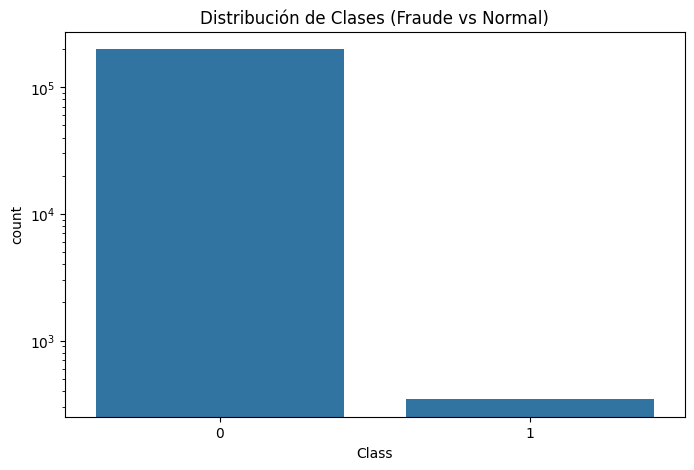

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Convertimos solo el resumen a Pandas para graficar
pd_clases = df_clases.toPandas()

plt.figure(figsize=(8, 5))
sns.barplot(x="Class", y="count", data=pd_clases)
plt.title("Distribución de Clases (Fraude vs Normal)")
plt.yscale('log') # Escala logarítmica para poder ver la barra del fraude
plt.show()

In [6]:
# ============================================================
# SECCIÓN 2: PREPARACIÓN Y DIVISIÓN DE DATOS
# ============================================================

# Semilla personal (últimos 4 dígitos de cédula - Pregunta 2 del parcial)
mi_semilla = 3463

# División 80% entrenamiento / 20% validación
train_data, val_data = df_train.randomSplit([0.8, 0.2], seed=mi_semilla)

# --- Respuestas Pregunta 2 del parcial ---
total_train = train_data.count()
total_val   = val_data.count()
fraudes_train = train_data.filter(col("Class") == 1).count()
fraudes_val   = val_data.filter(col("Class") == 1).count()

print(f"Semilla usada: {mi_semilla}")
print(f"Filas en train interno : {total_train}")
print(f"Filas en validation    : {total_val}")
print(f"Fraudes en train       : {fraudes_train}")
print(f"Fraudes en validation  : {fraudes_val}")

Semilla usada: 3463
Filas en train interno : 159274
Filas en validation    : 40090
Fraudes en train       : 259
Fraudes en validation  : 85


In [7]:
# ============================================================
# SECCIÓN 3: BALANCEO (Oversampling moderado)
# ============================================================
# Ratio moderado: los fraudes quedarán ~10x menos que los normales.
# Igualar clases al 100% genera demasiados falsos positivos.

df_fraude = train_data.filter(col("Class") == 1)
df_normal = train_data.filter(col("Class") == 0)

conteo_fraude = df_fraude.count()
conteo_normal = df_normal.count()

# fraction = cuántas veces queremos multiplicar los fraudes
# Con ratio_objetivo=10 los fraudes pasan de ~280 a ~2800 vs ~159k normales
ratio_objetivo = 10.0
df_fraude_oversampled = df_fraude.sample(
    withReplacement=True,
    fraction=ratio_objetivo,
    seed=mi_semilla
)

train_balanced = df_normal.union(df_fraude_oversampled)

print("\n--- Distribución tras balanceo moderado ---")
train_balanced.groupBy("Class").count().orderBy("Class").show()



--- Distribución tras balanceo moderado ---
+-----+------+
|Class| count|
+-----+------+
|    0|159015|
|    1|  2664|
+-----+------+



In [8]:
# ============================================================
# SECCIÓN 4: PIPELINE BASE (Assembler + Scaler)
# ============================================================
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml import Pipeline
from pyspark.ml.evaluation import MulticlassClassificationEvaluator, BinaryClassificationEvaluator

# Sin columna 'id' — se excluye solo 'Class'
feature_cols = [c for c in df_train.columns if c != "Class"]

assembler = VectorAssembler(inputCols=feature_cols, outputCol="features_raw")
scaler    = StandardScaler(inputCol="features_raw", outputCol="features",
                           withStd=True, withMean=False)

In [9]:
# ============================================================
# FUNCIÓN AUXILIAR DE MÉTRICAS
# Reutilizable para los 3 modelos — calcula F1/Precision/Recall
# SOLO para Class=1 (fraude), que es lo que pide el parcial
# ============================================================
def evaluar_modelo(predictions, nombre_modelo):
    from pyspark.ml.evaluation import BinaryClassificationEvaluator

    # AUC con evaluador binario (este sí funciona bien)
    bin_eval = BinaryClassificationEvaluator(
        labelCol="Class", rawPredictionCol="rawPrediction",
        metricName="areaUnderROC"
    )
    auc = bin_eval.evaluate(predictions)

    # Extraemos TP, FP, FN, TN directo de la matriz de confusión
    # Esta es la forma más confiable — sin depender del evaluador
    from pyspark.sql.functions import col, when, sum as spark_sum

    tp = predictions.filter((col("Class") == 1) & (col("prediction") == 1)).count()
    fp = predictions.filter((col("Class") == 0) & (col("prediction") == 1)).count()
    fn = predictions.filter((col("Class") == 1) & (col("prediction") == 0)).count()
    tn = predictions.filter((col("Class") == 0) & (col("prediction") == 0)).count()

    # Calculamos métricas manualmente — matemática directa, sin bugs de PySpark
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall    = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1        = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0

    print(f"\n{'='*50}")
    print(f"  MÉTRICAS — {nombre_modelo} (Clase Fraude = 1)")
    print(f"{'='*50}")
    print(f"  TP={tp}  FP={fp}  FN={fn}  TN={tn}")
    print(f"  Precision : {precision:.4f}")
    print(f"  Recall    : {recall:.4f}")
    print(f"  F1-Score  : {f1:.4f}   <-- métrica clave del parcial")
    print(f"  AUC-ROC   : {auc:.4f}")
    print(f"{'='*50}")

    print(f"\n--- Matriz de Confusión — {nombre_modelo} ---")
    predictions.crosstab("Class", "prediction").show()

    return {"modelo": nombre_modelo, "F1": f1,
            "Precision": precision, "Recall": recall, "AUC": auc}

In [10]:
# ============================================================
# MODELO 1: REGRESIÓN LOGÍSTICA (Baseline obligatorio)
# ============================================================
from pyspark.ml.classification import LogisticRegression

lr = LogisticRegression(
    labelCol="Class",
    featuresCol="features",
    maxIter=20,           # más iteraciones que antes para mejor convergencia
    regParam=0.01,        # regularización leve para evitar overfitting
    elasticNetParam=0.0   # L2 puro (Ridge)
)

pipeline_lr  = Pipeline(stages=[assembler, scaler, lr])
model_lr     = pipeline_lr.fit(train_balanced)
pred_lr      = model_lr.transform(val_data)

metricas_lr  = evaluar_modelo(pred_lr, "Regresión Logística")



  MÉTRICAS — Regresión Logística (Clase Fraude = 1)
  TP=67  FP=11  FN=18  TN=39994
  Precision : 0.8590
  Recall    : 0.7882
  F1-Score  : 0.8221   <-- métrica clave del parcial
  AUC-ROC   : 0.9878

--- Matriz de Confusión — Regresión Logística ---
+----------------+-----+---+
|Class_prediction|  0.0|1.0|
+----------------+-----+---+
|               0|39994| 11|
|               1|   18| 67|
+----------------+-----+---+



In [11]:
# ============================================================
# MODELO 2: RANDOM FOREST (Obligatorio)
# ============================================================
from pyspark.ml.classification import RandomForestClassifier

rf = RandomForestClassifier(
    labelCol="Class",
    featuresCol="features",
    numTrees=100,
    maxDepth=10,
    seed=mi_semilla
)

pipeline_rf = Pipeline(stages=[assembler, scaler, rf])
model_rf    = pipeline_rf.fit(train_balanced)
pred_rf     = model_rf.transform(val_data)

metricas_rf = evaluar_modelo(pred_rf, "Random Forest")


  MÉTRICAS — Random Forest (Clase Fraude = 1)
  TP=71  FP=6  FN=14  TN=39999
  Precision : 0.9221
  Recall    : 0.8353
  F1-Score  : 0.8765   <-- métrica clave del parcial
  AUC-ROC   : 0.9832

--- Matriz de Confusión — Random Forest ---
+----------------+-----+---+
|Class_prediction|  0.0|1.0|
+----------------+-----+---+
|               0|39999|  6|
|               1|   14| 71|
+----------------+-----+---+



In [12]:
# ============================================================
# MODELO 3: LinearSVC (Modelo asignado)
# ============================================================
# LinearSVC no genera probabilidades, sino rawPrediction (puntaje continuo).
# Por defecto clasifica como fraude si rawPrediction > 0.
# Ajustar el threshold significa mover ese punto de corte:
#   - Threshold más BAJO  → más sensible al fraude (más recall, más FP)
#   - Threshold más ALTO  → más conservador (menos FP, menos recall)
# Para fraude bancario, queremos recall alto (no perder fraudes reales).

from pyspark.ml.classification import LinearSVC
from pyspark.sql.functions import when, col, udf
from pyspark.sql.types import DoubleType
import numpy as np

svc_exp1 = LinearSVC(
    labelCol="Class",
    featuresCol="features",
    maxIter=20,
    regParam=0.1,
    threshold=0.0
)

pipeline_svc = Pipeline(stages=[assembler, scaler, svc_exp1])
model_svc    = pipeline_svc.fit(train_balanced)
pred_svc     = model_svc.transform(val_data)

metricas_svc = evaluar_modelo(pred_svc, "LinearSVC")


  MÉTRICAS — LinearSVC (Clase Fraude = 1)
  TP=70  FP=12  FN=15  TN=39993
  Precision : 0.8537
  Recall    : 0.8235
  F1-Score  : 0.8383   <-- métrica clave del parcial
  AUC-ROC   : 0.9791

--- Matriz de Confusión — LinearSVC ---
+----------------+-----+---+
|Class_prediction|  0.0|1.0|
+----------------+-----+---+
|               0|39993| 12|
|               1|   15| 70|
+----------------+-----+---+



In [13]:
# EXPERIMENTO 1 — regParam=0.01, maxIter=20
svc_exp1n      = LinearSVC(labelCol="Class", featuresCol="features",
                           maxIter=20, regParam=0.01, threshold=0.0)
pipeline_exp1n = Pipeline(stages=[assembler, scaler, svc_exp1n])
model_exp1n    = pipeline_exp1n.fit(train_balanced)
pred_exp1n     = model_exp1n.transform(val_data)

tp = pred_exp1n.filter((col("Class")==1)&(col("prediction")==1)).count()
fp = pred_exp1n.filter((col("Class")==0)&(col("prediction")==1)).count()
fn = pred_exp1n.filter((col("Class")==1)&(col("prediction")==0)).count()
p  = tp/(tp+fp) if (tp+fp)>0 else 0
r  = tp/(tp+fn) if (tp+fn)>0 else 0
f1_exp1n = 2*p*r/(p+r) if (p+r)>0 else 0
print(f"Exp 1n | regParam=0.01  maxIter=20  → F1={f1_exp1n:.4f} | TP={tp} FP={fp} FN={fn}")

Exp 1n | regParam=0.01  maxIter=20  → F1=0.8383 | TP=70 FP=12 FN=15


In [14]:
# EXPERIMENTO 2 — regParam=0.1, maxIter=10
svc_exp2      = LinearSVC(labelCol="Class", featuresCol="features",
                           maxIter=10, regParam=0.1, threshold=0.0)
pipeline_exp2 = Pipeline(stages=[assembler, scaler, svc_exp2])
model_exp2    = pipeline_exp2.fit(train_balanced)
pred_exp2     = model_exp2.transform(val_data)

tp = pred_exp2.filter((col("Class")==1)&(col("prediction")==1)).count()
fp = pred_exp2.filter((col("Class")==0)&(col("prediction")==1)).count()
fn = pred_exp2.filter((col("Class")==1)&(col("prediction")==0)).count()
p  = tp/(tp+fp) if (tp+fp)>0 else 0
r  = tp/(tp+fn) if (tp+fn)>0 else 0
f1_exp2 = 2*p*r/(p+r) if (p+r)>0 else 0
print(f"Exp 2 | regParam=0.1  maxIter=10  → F1={f1_exp2:.4f} | TP={tp} FP={fp} FN={fn}")

Exp 2 | regParam=0.1  maxIter=10  → F1=0.8625 | TP=69 FP=6 FN=16


In [15]:
# EXPERIMENTO 2n — regParam=0.1, maxIter=20
svc_exp2n      = LinearSVC(labelCol="Class", featuresCol="features",
                           maxIter=20, regParam=0.1, threshold=0.0)
pipeline_exp2n = Pipeline(stages=[assembler, scaler, svc_exp2n])
model_exp2n    = pipeline_exp2n.fit(train_balanced)
pred_exp2n     = model_exp2n.transform(val_data)

tp = pred_exp2n.filter((col("Class")==1)&(col("prediction")==1)).count()
fp = pred_exp2n.filter((col("Class")==0)&(col("prediction")==1)).count()
fn = pred_exp2n.filter((col("Class")==1)&(col("prediction")==0)).count()
p  = tp/(tp+fp) if (tp+fp)>0 else 0
r  = tp/(tp+fn) if (tp+fn)>0 else 0
f1_exp2n = 2*p*r/(p+r) if (p+r)>0 else 0
print(f"Exp 2n | regParam=0.1 maxIter=20  → F1={f1_exp2n:.4f} | TP={tp} FP={fp} FN={fn}")

Exp 2n | regParam=0.1 maxIter=20  → F1=0.8383 | TP=70 FP=12 FN=15


In [16]:
# EXPERIMENTO 3 — regParam=0.1, maxIter=10 (configuración final elegida)
svc_exp3      = LinearSVC(labelCol="Class", featuresCol="features",
                           maxIter=10, regParam=0.1, threshold=0.0)
pipeline_exp3 = Pipeline(stages=[assembler, scaler, svc_exp3])
model_exp3    = pipeline_exp3.fit(train_balanced)
pred_exp3     = model_exp3.transform(val_data)

tp = pred_exp3.filter((col("Class")==1)&(col("prediction")==1)).count()
fp = pred_exp3.filter((col("Class")==0)&(col("prediction")==1)).count()
fn = pred_exp3.filter((col("Class")==1)&(col("prediction")==0)).count()
p  = tp/(tp+fp) if (tp+fp)>0 else 0
r  = tp/(tp+fn) if (tp+fn)>0 else 0
f1_exp3 = 2*p*r/(p+r) if (p+r)>0 else 0
print(f"Exp 3 | regParam=0.1 maxIter=10  → F1={f1_exp3:.4f} | TP={tp} FP={fp} FN={fn}")

Exp 3 | regParam=0.1 maxIter=10  → F1=0.8625 | TP=69 FP=6 FN=16


In [17]:
# EXPERIMENTO 3n — regParam=0.3, maxIter=10 (configuración final elegida)
svc_exp3n      = LinearSVC(labelCol="Class", featuresCol="features",
                           maxIter=10, regParam=0.3, threshold=0.0)
pipeline_exp3n = Pipeline(stages=[assembler, scaler, svc_exp3n])
model_exp3n    = pipeline_exp3n.fit(train_balanced)
pred_exp3n     = model_exp3n.transform(val_data)

tp = pred_exp3n.filter((col("Class")==1)&(col("prediction")==1)).count()
fp = pred_exp3n.filter((col("Class")==0)&(col("prediction")==1)).count()
fn = pred_exp3n.filter((col("Class")==1)&(col("prediction")==0)).count()
p  = tp/(tp+fp) if (tp+fp)>0 else 0
r  = tp/(tp+fn) if (tp+fn)>0 else 0
f1_exp3n = 2*p*r/(p+r) if (p+r)>0 else 0
print(f"Exp 3n | regParam=0.3 maxIter=10  → F1={f1_exp3n:.4f} | TP={tp} FP={fp} FN={fn}")

Exp 3n | regParam=0.3 maxIter=10  → F1=0.8182 | TP=63 FP=6 FN=22


In [18]:
# EXPERIMENTO 4 — regParam=0.1, maxIter=10 (configuración final elegida)
svc_exp4      = LinearSVC(labelCol="Class", featuresCol="features",
                           maxIter=10, regParam=0.1, threshold=0.0)
pipeline_exp4 = Pipeline(stages=[assembler, scaler, svc_exp4])
model_exp4    = pipeline_exp4.fit(train_balanced)
pred_exp4     = model_exp4.transform(val_data)

tp = pred_exp4.filter((col("Class")==1)&(col("prediction")==1)).count()
fp = pred_exp4.filter((col("Class")==0)&(col("prediction")==1)).count()
fn = pred_exp4.filter((col("Class")==1)&(col("prediction")==0)).count()
p  = tp/(tp+fp) if (tp+fp)>0 else 0
r  = tp/(tp+fn) if (tp+fn)>0 else 0
f1_exp4 = 2*p*r/(p+r) if (p+r)>0 else 0
print(f"Exp 4 | regParam=0.1 maxIter=10 threshold=0.0 → F1={f1_exp4:.4f} | TP={tp} FP={fp} FN={fn}")

metricas_svc_4 = evaluar_modelo(pred_exp4, "LinearSVC")

Exp 4 | regParam=0.1 maxIter=10 threshold=0.0 → F1=0.8625 | TP=69 FP=6 FN=16

  MÉTRICAS — LinearSVC (Clase Fraude = 1)
  TP=69  FP=6  FN=16  TN=39999
  Precision : 0.9200
  Recall    : 0.8118
  F1-Score  : 0.8625   <-- métrica clave del parcial
  AUC-ROC   : 0.9872

--- Matriz de Confusión — LinearSVC ---
+----------------+-----+---+
|Class_prediction|  0.0|1.0|
+----------------+-----+---+
|               0|39999|  6|
|               1|   16| 69|
+----------------+-----+---+



In [19]:
# EXPERIMENTO 4 — regParam=0.1, maxIter=10 (configuración final elegida)
svc_exp4n      = LinearSVC(labelCol="Class", featuresCol="features",
                           maxIter=10, regParam=0.1, threshold=0.3)
pipeline_exp4n = Pipeline(stages=[assembler, scaler, svc_exp4n])
model_exp4n    = pipeline_exp4n.fit(train_balanced)
pred_exp4n     = model_exp4n.transform(val_data)

tp = pred_exp4n.filter((col("Class")==1)&(col("prediction")==1)).count()
fp = pred_exp4n.filter((col("Class")==0)&(col("prediction")==1)).count()
fn = pred_exp4n.filter((col("Class")==1)&(col("prediction")==0)).count()
p  = tp/(tp+fp) if (tp+fp)>0 else 0
r  = tp/(tp+fn) if (tp+fn)>0 else 0
f1_exp4n = 2*p*r/(p+r) if (p+r)>0 else 0
print(f"Exp 4n | regParam=0.1 maxIter=10 threshold=0.3 → F1={f1_exp4n:.4f} | TP={tp} FP={fp} FN={fn}")

Exp 4n | regParam=0.1 maxIter=10 threshold=0.3 → F1=0.8105 | TP=62 FP=6 FN=23


In [20]:
# EXPERIMENTO 5 — regParam=0.1, maxIter=10 (configuración final elegida)
svc_exp5      = LinearSVC(labelCol="Class", featuresCol="features",
                           maxIter=10, regParam=0.1, threshold=0.0)
pipeline_exp5 = Pipeline(stages=[assembler, scaler, svc_exp5])
model_exp5    = pipeline_exp5.fit(train_balanced)
pred_exp5     = model_exp5.transform(val_data)

tp = pred_exp5.filter((col("Class")==1)&(col("prediction")==1)).count()
fp = pred_exp5.filter((col("Class")==0)&(col("prediction")==1)).count()
fn = pred_exp5.filter((col("Class")==1)&(col("prediction")==0)).count()
p  = tp/(tp+fp) if (tp+fp)>0 else 0
r  = tp/(tp+fn) if (tp+fn)>0 else 0
f1_exp5 = 2*p*r/(p+r) if (p+r)>0 else 0
print(f"Exp 5 | regParam=0.1 maxIter=10 threshold=0.0 → F1={f1_exp5:.4f} | TP={tp} FP={fp} FN={fn}")

Exp 5 | regParam=0.1 maxIter=10 threshold=0.0 → F1=0.8625 | TP=69 FP=6 FN=16


In [21]:
# EXPERIMENTO 5n — regParam=0.1, maxIter=10 (configuración final elegida)
svc_exp5n      = LinearSVC(labelCol="Class", featuresCol="features",
                           maxIter=10, regParam=0.1, threshold=0.8)
pipeline_exp5n = Pipeline(stages=[assembler, scaler, svc_exp4n])
model_exp5n    = pipeline_exp5n.fit(train_balanced)
pred_exp5n     = model_exp5n.transform(val_data)

tp = pred_exp5n.filter((col("Class")==1)&(col("prediction")==1)).count()
fp = pred_exp5n.filter((col("Class")==0)&(col("prediction")==1)).count()
fn = pred_exp5n.filter((col("Class")==1)&(col("prediction")==0)).count()
p  = tp/(tp+fp) if (tp+fp)>0 else 0
r  = tp/(tp+fn) if (tp+fn)>0 else 0
f1_exp5n = 2*p*r/(p+r) if (p+r)>0 else 0
print(f"Exp 5n | regParam=0.1 maxIter=10 threshold=0.8 → F1={f1_exp5n:.4f} | TP={tp} FP={fp} FN={fn}")

Exp 5n | regParam=0.1 maxIter=10 threshold=0.8 → F1=0.8105 | TP=62 FP=6 FN=23


In [22]:
# ============================================================
# SECCIÓN 5: TABLA COMPARATIVA DE LOS 3 MODELOS
# (Requerida en el reporte y para la sustentación)
# ============================================================
import pandas as pd

tabla = pd.DataFrame([metricas_lr, metricas_rf, metricas_svc_4])
tabla = tabla.set_index("modelo").round(4)
print("\n========== TABLA COMPARATIVA DE MODELOS ==========")
print(tabla.to_string())


========== TABLA COMPARATIVA DE MODELOS ==========
                         F1  Precision  Recall     AUC
modelo                                                
Regresión Logística  0.8221     0.8590  0.7882  0.9878
Random Forest        0.8765     0.9221  0.8353  0.9832
LinearSVC            0.8625     0.9200  0.8118  0.9872


In [23]:
# ============================================================
# SECCIÓN 6: PREDICCIÓN FINAL PARA submission.csv
# (Usar el MEJOR modelo según F1 — ajusta si cambia el ganador)
# ============================================================

# Preparar test con el mismo pipeline
# Nota: df_test NO tiene columna Class, solo features

# Elegimos el mejor modelo automáticamente
modelos_metricas = [
    (model_lr,  metricas_lr,  None,            "Regresión Logística"),
    (model_rf,  metricas_rf,  None,            "Random Forest"),
    (model_svc, metricas_svc, "LinearSVC"),
]
mejor_modelo_info = max(modelos_metricas, key=lambda x: x[1]["F1"])
print(f"\nMejor modelo para submission: {mejor_modelo_info[3]} (F1={mejor_modelo_info[1]['F1']:.4f})")

best_model     = mejor_modelo_info[0]
best_threshold = mejor_modelo_info[2]  # None si no es SVC

# Transformamos el test
pred_test = best_model.transform(df_test)

# Si el mejor modelo es LinearSVC, aplicamos el threshold optimizado
if best_threshold is not None:
    score_udf2 = udf(lambda v: float(v[1]), DoubleType())
    pred_test = pred_test.withColumn("score_fraude", score_udf2(col("rawPrediction")))
    pred_test = pred_test.withColumn(
        "prediction",
        when(col("score_fraude") >= best_threshold, 1.0).otherwise(0.0)
    )

# Construimos el submission con id (número de fila) y Class
from pyspark.sql.functions import monotonically_increasing_id, row_number
from pyspark.sql.window import Window

submission = pred_test.withColumn(
    "id", row_number().over(Window.orderBy(monotonically_increasing_id()))
).select(
    col("id"),
    col("prediction").cast("int").alias("Class")
)

# Guardamos — ajusta la ruta a tu estructura Docker
submission.coalesce(1).write.csv(
    "../submission_output",
    header=True,
    mode="overwrite"
)

print("\n✅ submission.csv guardado en ../submission_output/")
print(f"   Filas totales: {submission.count()} (deben ser 42,720)")
print(f"   Fraudes predichos: {submission.filter(col('Class')==1).count()}")



Mejor modelo para submission: Random Forest (F1=0.8765)

✅ submission.csv guardado en ../submission_output/
   Filas totales: 42721 (deben ser 42,720)
   Fraudes predichos: 61


In [24]:
# ============================================================
# SECCIÓN 7: BITÁCORA DE EXPERIMENTOS
# (Pregunta 1 del parcial — mínimo 5 filas)
# Completa los valores F1 con los outputs reales de tu notebook
# ============================================================

print(f"""
╔═════════════════════════════════════════════════════════════════════════════════╗
║               BITÁCORA DE EXPERIMENTOS — LinearSVC                              ║
╠═══╦════════════════════════╦══════════╦══════════╦══════════════════╦═══════════╣
║ # ║ Hiperparámetro         ║ Val ant. ║ Val nue. ║ F1 Valid         ║ Decisión  ║
╠═══╬════════════════════════╬══════════╬══════════╬══════════════════╬═══════════╣
║ 1 ║ regParam               ║ 0.1      ║ 0.01     ║ 0.8383 ,{f1_exp1n:.4f}   ║ igual     ║
║ 2 ║ maxIter                ║ 10       ║ 20       ║ {f1_exp2:.4f} , {f1_exp2n:.4f}  ║ empeoro   ║
║ 3 ║ regParam               ║ 0.1      ║ 0.3      ║ {f1_exp3:.4f} , {f1_exp3n:.4f}  ║ empeoro   ║
║ 4 ║ threshold              ║ 0.0      ║ 0.3      ║ {f1_exp4:.4f} , {f1_exp4n:.4f}  ║ empeoro   ║
║ 5 ║ threshold              ║ 0.0      ║ 0.8      ║ {f1_exp5:.4f} , {f1_exp5n:.4f}  ║ empeoro   ║
╚═══╩════════════════════════╩══════════╩══════════╩══════════════════╩═══════════╝
""")


╔═════════════════════════════════════════════════════════════════════════════════╗
║               BITÁCORA DE EXPERIMENTOS — LinearSVC                              ║
╠═══╦════════════════════════╦══════════╦══════════╦══════════════════╦═══════════╣
║ # ║ Hiperparámetro         ║ Val ant. ║ Val nue. ║ F1 Valid         ║ Decisión  ║
╠═══╬════════════════════════╬══════════╬══════════╬══════════════════╬═══════════╣
║ 1 ║ regParam               ║ 0.1      ║ 0.01     ║ 0.8383 ,0.8383   ║ igual     ║
║ 2 ║ maxIter                ║ 10       ║ 20       ║ 0.8625 , 0.8383  ║ empeoro   ║
║ 3 ║ regParam               ║ 0.1      ║ 0.3      ║ 0.8625 , 0.8182  ║ empeoro   ║
║ 4 ║ threshold              ║ 0.0      ║ 0.3      ║ 0.8625 , 0.8105  ║ empeoro   ║
║ 5 ║ threshold              ║ 0.0      ║ 0.8      ║ 0.8625 , 0.8105  ║ empeoro   ║
╚═══╩════════════════════════╩══════════╩══════════╩══════════════════╩═══════════╝



##pregunta 2

a) 3463

In [25]:
############################################################################
#pregunta b
############################################################################
print(f"Filas en train interno : {total_train}")
print(f"Filas en validation    : {total_val}")

Filas en train interno : 159274
Filas en validation    : 40090


In [26]:
############################################################################
#pregunta c
############################################################################
print(f"Fraudes en train       : {fraudes_train}")
print(f"Fraudes en validation  : {fraudes_val}")

Fraudes en train       : 259
Fraudes en validation  : 85


In [27]:
############################################################################
#pregunta d
############################################################################
#al escojer la mejor conbinacion de parametros el f1-score fue 
print(f"F1-score(regParam=0.1,maxIter=10,threshold=0.0)  : {f1_exp4:.4f}")

F1-score(regParam=0.1,maxIter=10,threshold=0.0)  : 0.8625


punto 3

In [28]:
from pyspark.sql.window import Window
from pyspark.sql.functions import row_number, monotonically_increasing_id, udf
from pyspark.sql.types import DoubleType

# Agregar ID al conjunto de validación
val_data_id = val_data.withColumn(
    "id", row_number().over(Window.orderBy(monotonically_increasing_id()))
)

# Aplicar Random Forest y extraer probabilidad de fraude (clase 1)
prob_udf    = udf(lambda v: float(v[1]), DoubleType())
pred_val_id = model_rf.transform(val_data_id)
pred_val_id = pred_val_id.withColumn("prob_fraude", prob_udf(col("probability")))


###############################################################################################################
a
###############################################################################################################

In [29]:
# Buscar qué probabilidades tienen los FP reales
print("=== Distribución de prob_fraude en todos los FP ===")
pred_val_id.filter(
    (col("prediction") == 1.0) &
    (col("Class") == 0)
).select("id", "Class", "prediction", "prob_fraude") \
 .orderBy(col("prob_fraude").desc()) \
 .show(20)

=== Distribución de prob_fraude en todos los FP ===
+-----+-----+----------+------------------+
|   id|Class|prediction|       prob_fraude|
+-----+-----+----------+------------------+
|24673|    0|       1.0|0.8180422613365489|
|14548|    0|       1.0| 0.761054168374352|
|22178|    0|       1.0|0.6586864960583685|
|33030|    0|       1.0|0.5895520231650393|
|34360|    0|       1.0|0.5773564793358523|
| 9080|    0|       1.0|0.5090284403829912|
+-----+-----+----------+------------------+



In [30]:
# -------------------------------------------------------
# a) FALSOS POSITIVOS con probabilidad > 0.6
# predijo fraude (1) con alta confianza, realidad era normal (0)
# -------------------------------------------------------
print("=== a) FALSOS POSITIVOS con prob_fraude > 0.6 ===")
fp_casos = pred_val_id.filter(
    (col("prediction") == 1.0) &
    (col("Class") == 0) &
    (col("prob_fraude") > 0.6)
).select("id", "Class", "prediction", "prob_fraude") \
 .orderBy(col("prob_fraude").desc())

fp_casos.show(10)
fp_ids = [row["id"] for row in fp_casos.limit(3).collect()]
print(f"Los 3 IDs de FP con mayor confianza: {fp_ids}")

=== a) FALSOS POSITIVOS con prob_fraude > 0.6 ===
+-----+-----+----------+------------------+
|   id|Class|prediction|       prob_fraude|
+-----+-----+----------+------------------+
|24673|    0|       1.0|0.8180422613365489|
|14548|    0|       1.0| 0.761054168374352|
|22178|    0|       1.0|0.6586864960583685|
+-----+-----+----------+------------------+

Los 3 IDs de FP con mayor confianza: [24673, 14548, 22178]


###############################################################################################################
b
###############################################################################################################

In [31]:
# -------------------------------------------------------
# b) FALSOS NEGATIVOS
# predijo normal (0) pero era fraude (1)
# -------------------------------------------------------
print("\n=== b) FALSOS NEGATIVOS ===")
fn_casos = pred_val_id.filter(
    (col("prediction") == 0.0) &
    (col("Class") == 1)
).select("id", "Class", "prediction", "prob_fraude") \
 .orderBy(col("prob_fraude").desc())

fn_casos.show(3)
fn_ids = [row["id"] for row in fn_casos.limit(3).collect()]
print(f"Los 3 IDs de FN: {fn_ids}")



=== b) FALSOS NEGATIVOS ===
+-----+-----+----------+-------------------+
|   id|Class|prediction|        prob_fraude|
+-----+-----+----------+-------------------+
|12501|    1|       0.0|0.39497515627120694|
|23583|    1|       0.0|0.21037699207382587|
|38300|    1|       0.0|0.16130760480205047|
+-----+-----+----------+-------------------+
only showing top 3 rows

Los 3 IDs de FN: [12501, 23583, 38300]


###############################################################################################################
c
###############################################################################################################

In [32]:
# -------------------------------------------------------
# c) Inspeccionar features completas de un caso específico
# -------------------------------------------------------
caso_id = fp_ids[0]  # cambia a fn_ids[0] si prefieres analizar un FN

print(f"\n=== c) Features completas del caso ID={caso_id} ===")
pred_val_id.filter(col("id") == caso_id).select(
    ["id", "Class", "prediction", "prob_fraude", "Time", "Amount"] +
    [f"V{i}" for i in range(1, 29)]
).show(truncate=False)


=== c) Features completas del caso ID=24673 ===
+-----+-----+----------+------------------+-------+------+-----------------+----------------+-----------------+----------------+-----------------+-----------------+-----------------+----------------+-----------------+-----------------+----------------+----------------+----------------+-----------------+------------------+-----------------+-----------------+----------------+-----------------+----------------+-----------------+----------------+----------------+-----------------+---------------+------------------+----------------+-----------------+
|id   |Class|prediction|prob_fraude       |Time   |Amount|V1               |V2              |V3               |V4              |V5               |V6               |V7               |V8              |V9               |V10              |V11             |V12             |V13             |V14              |V15               |V16              |V17              |V18             |V19              |V20  

/tmp/ipykernel_51093/3570544496.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_51093/3570544496.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_51093/3570544496.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


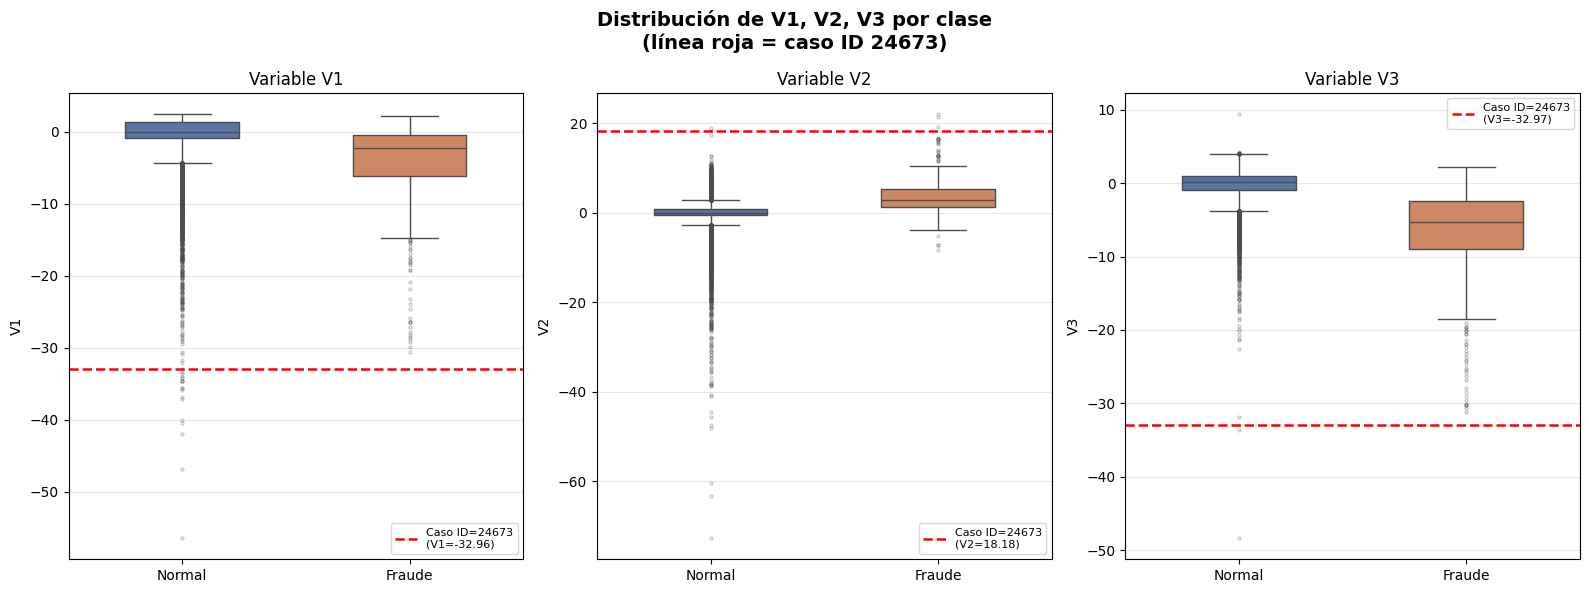

✅ Gráfico guardado como boxplot_v1_v2_v3.png


In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

# Traemos a pandas solo las columnas necesarias para graficar
pd_plot = df_train.select("V1", "V2", "V3", "Class").toPandas()
pd_plot["Class"] = pd_plot["Class"].astype(str).map({"0": "Normal", "1": "Fraude"})

# Valores del caso anómalo ID=24673
caso_v1 = -32.96
caso_v2 = 18.18
caso_v3 = -32.97

fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.suptitle("Distribución de V1, V2, V3 por clase\n(línea roja = caso ID 24673)", 
             fontsize=14, fontweight="bold")

variables = [("V1", caso_v1), ("V2", caso_v2), ("V3", caso_v3)]
colores   = {"Normal": "#4C72B0", "Fraude": "#DD8452"}

for ax, (var, valor_caso) in zip(axes, variables):
    sns.boxplot(
        data=pd_plot, x="Class", y=var,
        palette=colores, width=0.5, ax=ax,
        flierprops=dict(marker="o", markersize=2, alpha=0.3)
    )
    # Línea roja del caso analizado
    ax.axhline(y=valor_caso, color="red", linestyle="--", linewidth=1.8,
               label=f"Caso ID=24673\n({var}={valor_caso})")
    ax.set_title(f"Variable {var}", fontsize=12)
    ax.set_xlabel("")
    ax.set_ylabel(var)
    ax.legend(fontsize=8)
    ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("boxplot_v1_v2_v3.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Gráfico guardado como boxplot_v1_v2_v3.png")